# Probability Mass Function-Descrite values

In [2]:
import pandas as pd

In [3]:
import random

In [4]:
l=[]
for i in range(1000):
    s=random.randint(1,6)
    b=random.randint(1,6)
    l.append(s+b)

In [5]:
len(l)

1000

In [6]:
l[:6]

[8, 8, 5, 9, 7, 7]

In [7]:
s=(pd.Series(l).value_counts()/(pd.Series(l).value_counts().sum())).sort_index()

In [8]:
s

2     0.027
3     0.064
4     0.078
5     0.107
6     0.146
7     0.153
8     0.141
9     0.113
10    0.083
11    0.056
12    0.032
Name: count, dtype: float64

<Axes: >

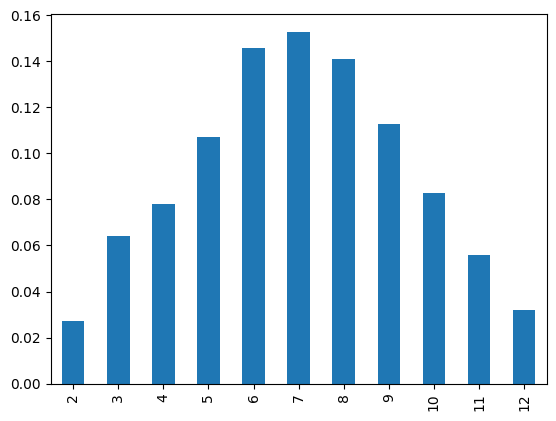

In [9]:
s.plot(kind='bar')

In [10]:
import numpy as np
np.cumsum(s)

2     0.027
3     0.091
4     0.169
5     0.276
6     0.422
7     0.575
8     0.716
9     0.829
10    0.912
11    0.968
12    1.000
Name: count, dtype: float64

Commulative distribution from PMF -it gives probablity of all the points upto x

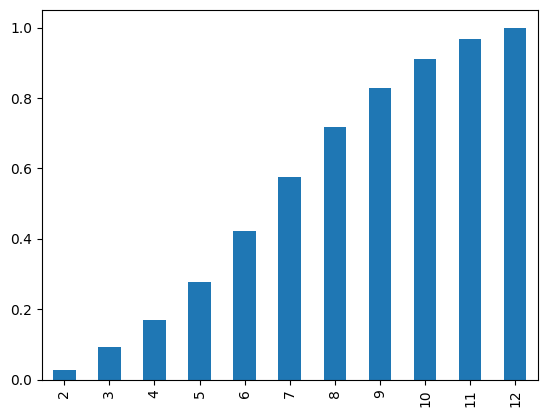

In [11]:
s=np.cumsum(s).plot(kind='bar')

# Probability Density Function

## Parametric Density Estimation

In [12]:
import matplotlib.pyplot as plt
import numpy as np

In [13]:
from numpy.random import normal

In [14]:
sample=normal(loc=50 , scale=5,size=1000)#loc-mean ,scale-std

In [15]:
sample.mean()

50.19135058182526

In [16]:
# plot histogram to understyand the data

(array([ 10.,  16.,  83., 141., 229., 221., 184.,  73.,  39.,   4.]),
 array([34.34869828, 37.46527218, 40.58184609, 43.69841999, 46.8149939 ,
        49.93156781, 53.04814171, 56.16471562, 59.28128952, 62.39786343,
        65.51443733]),
 <BarContainer object of 10 artists>)

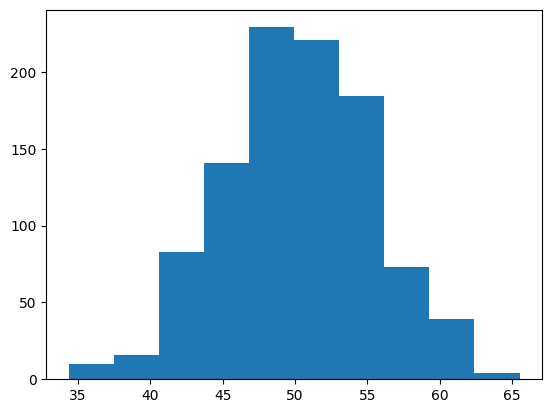

In [18]:
plt.hist(sample , bins=10)

In [19]:
# calculate the sample mean and std dev

sample_mean=sample.mean()
sample_std=sample.std()

In [20]:
#fit the distribution to the aabove parameter

from scipy.stats import norm
dist=norm(sample_mean,sample_std)

In [21]:
# generating 100 vlue to plt between sample min , max

values=np.linspace(sample.min(),sample.max(),100)

In [22]:
values

array([34.34869828, 34.66350372, 34.97830917, 35.29311461, 35.60792006,
       35.9227255 , 36.23753095, 36.55233639, 36.86714184, 37.18194728,
       37.49675273, 37.81155817, 38.12636362, 38.44116906, 38.75597451,
       39.07077995, 39.3855854 , 39.70039084, 40.01519629, 40.33000173,
       40.64480718, 40.95961262, 41.27441807, 41.58922351, 41.90402896,
       42.2188344 , 42.53363985, 42.84844529, 43.16325074, 43.47805618,
       43.79286163, 44.10766707, 44.42247252, 44.73727796, 45.05208341,
       45.36688885, 45.6816943 , 45.99649974, 46.31130519, 46.62611063,
       46.94091608, 47.25572152, 47.57052697, 47.88533241, 48.20013786,
       48.5149433 , 48.82974875, 49.14455419, 49.45935964, 49.77416508,
       50.08897053, 50.40377597, 50.71858142, 51.03338686, 51.34819231,
       51.66299775, 51.9778032 , 52.29260864, 52.60741409, 52.92221953,
       53.23702498, 53.55183042, 53.86663587, 54.18144131, 54.49624676,
       54.8110522 , 55.12585765, 55.44066309, 55.75546854, 56.07

In [23]:
probability_density=[dist.pdf(value) for value in values]

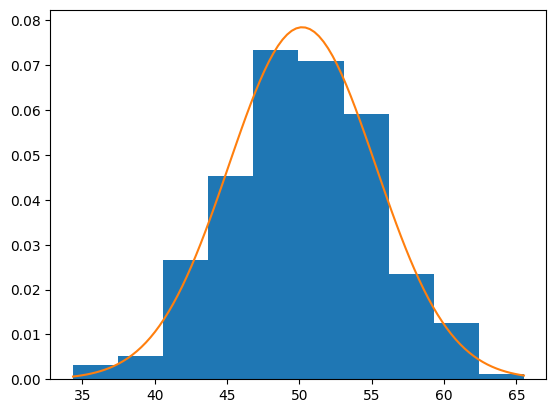

In [24]:
#plot the histogram and pdf

plt.hist(sample,bins=10,density=True)
plt.plot(values,probability_density)

C:\Users\Strange\AppData\Local\Temp\ipykernel_22656\1482356190.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(sample)


<Axes: ylabel='Density'>

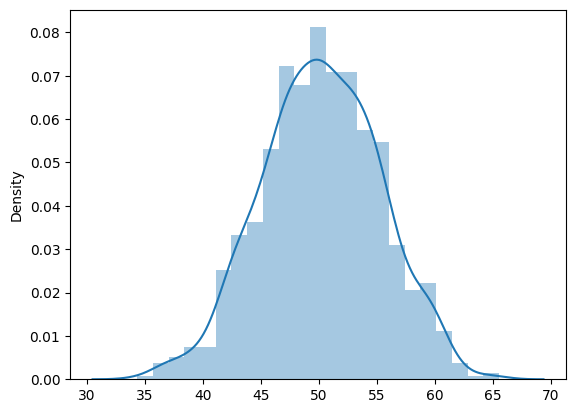

In [25]:
import seaborn as sns
sns.distplot(sample)

## Non peramatric Density Estimation

### Kernel Density Estimation

In [70]:
#geterate the sample

sample1=normal(loc=20,scale=5,size=300)
sample2=normal(loc=40,scale=5,size=700)
sample=np.hstack((sample1,sample2))

(array([ 2.,  2.,  2.,  3.,  2.,  8., 13., 12.,  9., 22., 19., 22., 17.,
        28., 17., 26., 20., 18., 22.,  8., 12., 11., 11.,  5., 14., 22.,
        20., 23., 25., 37., 53., 45., 54., 52., 47., 65., 31., 43., 39.,
        25., 30.,  6., 19., 14.,  6.,  7.,  5.,  3.,  1.,  3.]),
 array([ 7.0753029 ,  8.04966244,  9.02402199,  9.99838153, 10.97274107,
        11.94710062, 12.92146016, 13.8958197 , 14.87017925, 15.84453879,
        16.81889833, 17.79325788, 18.76761742, 19.74197696, 20.71633651,
        21.69069605, 22.66505559, 23.63941514, 24.61377468, 25.58813422,
        26.56249377, 27.53685331, 28.51121285, 29.4855724 , 30.45993194,
        31.43429148, 32.40865103, 33.38301057, 34.35737011, 35.33172966,
        36.3060892 , 37.28044874, 38.25480829, 39.22916783, 40.20352737,
        41.17788692, 42.15224646, 43.12660601, 44.10096555, 45.07532509,
        46.04968464, 47.02404418, 47.99840372, 48.97276327, 49.94712281,
        50.92148235, 51.8958419 , 52.87020144, 53.84456098,

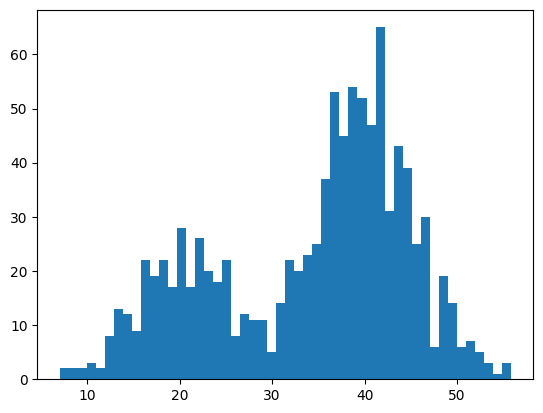

In [71]:
plt.hist(sample,bins=50)

In [72]:
from sklearn.neighbors import KernelDensity

model=KernelDensity(bandwidth=5 , kernel='gaussian')

In [73]:
sample.shape

(1000,)

In [74]:
#convert to 2d
sample=sample.reshape(len(sample),1)
model.fit(sample)

,bandwidth,5
,algorithm,'auto'
,kernel,'gaussian'
,metric,'euclidean'
,atol,0
,rtol,0
,breadth_first,True
,leaf_size,40
,metric_params,None


In [75]:
values=np.linspace(sample.min(),sample.max(),100)
values=values.reshape(len(values),1)

In [76]:
probabilities=model.score_samples(values)
probabilities = np.exp(probabilities)

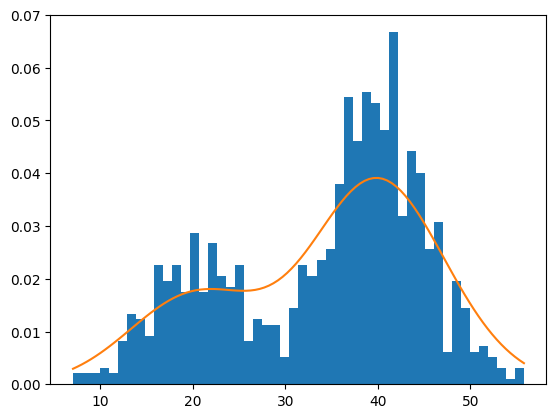

In [78]:
plt.hist(sample,bins=50,density=True)
plt.plot(values,probabilities)
plt.show()

<Axes: ylabel='Density'>

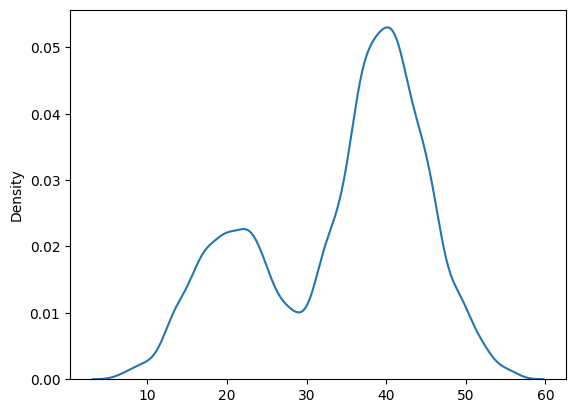

In [85]:
sns.kdeplot(sample.reshape(1000),bw_adjust=0.5)

In [49]:
import seaborn as sns

In [50]:
df=sns.load_dataset('iris')

In [113]:
df.head(5)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


C:\Users\Strange\AppData\Local\Temp\ipykernel_10824\537145680.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['sepal_length'])


<Axes: xlabel='sepal_length', ylabel='Density'>

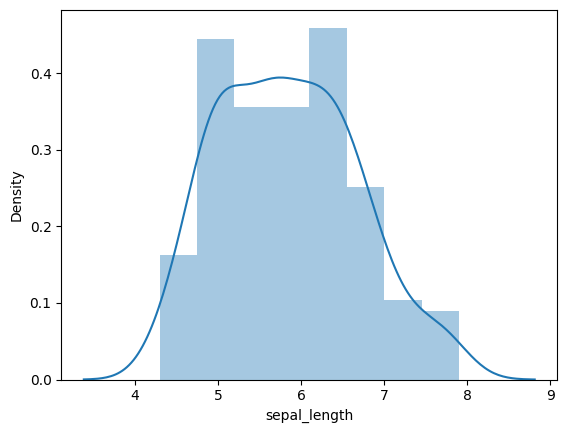

In [51]:
sns.distplot(df['sepal_length'])

In [55]:
import pandas as pd
df['sepal_length'].skew()

0.3149109566369728

<Axes: xlabel='sepal_length', ylabel='Density'>

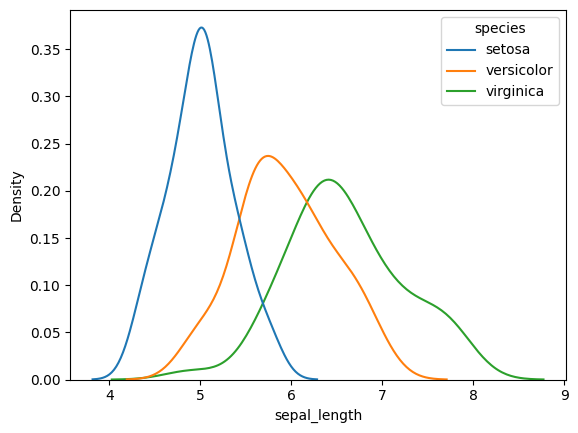

In [114]:
sns.kdeplot(data=df ,x='sepal_length',hue='species')

<Axes: xlabel='sepal_width', ylabel='Density'>

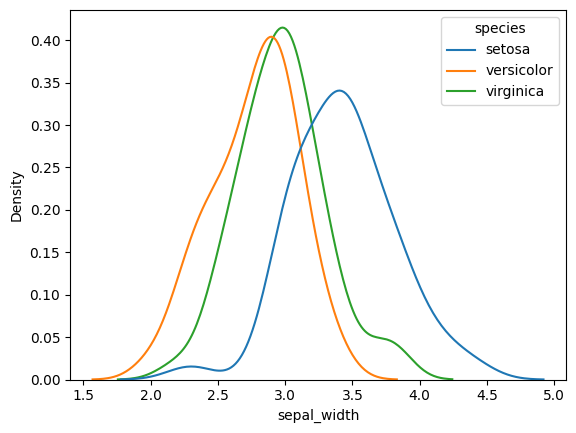

In [115]:
sns.kdeplot(data=df,x='sepal_width',hue='species')

<Axes: xlabel='petal_length', ylabel='Density'>

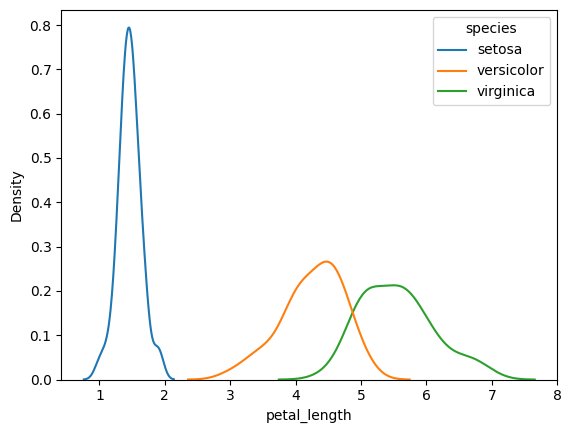

In [116]:
sns.kdeplot(data=df,x='petal_length',hue='species')

<Axes: xlabel='petal_width', ylabel='Density'>

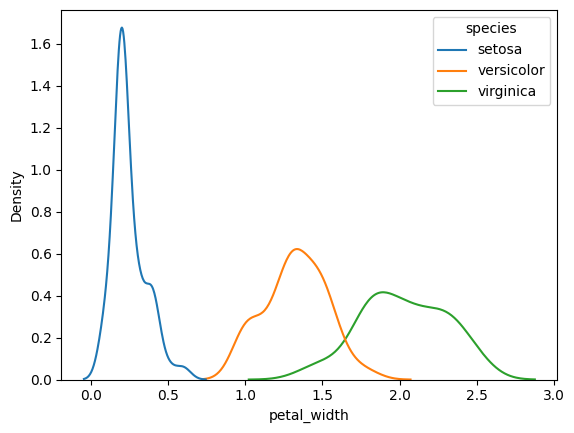

In [117]:
sns.kdeplot(data=df,x='petal_width',hue='species')

In [118]:
#cdf 

<Axes: xlabel='petal_width', ylabel='Density'>

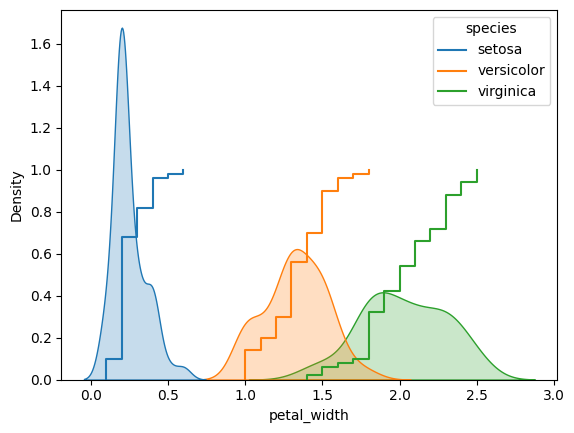

In [122]:
sns.kdeplot(data=df, x='petal_width', hue='species', fill=True)
sns.ecdfplot(data=df,x='petal_width',hue='species')

In [123]:
titanic = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')

In [124]:
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


<Axes: xlabel='Age', ylabel='Density'>

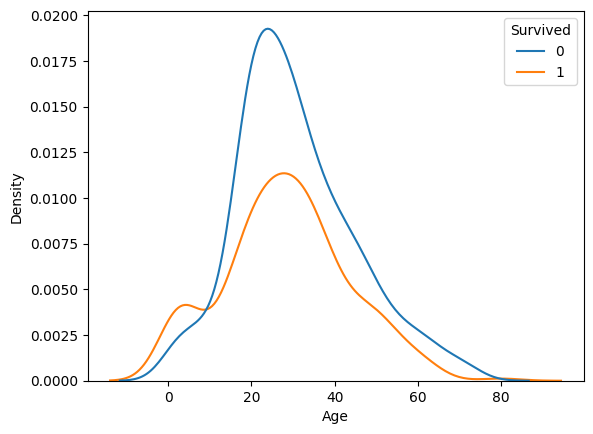

In [125]:
sns.kdeplot(data=titanic,x='Age',hue='Survived')

In [ ]:
#if age is less 15 then survived or else dieed

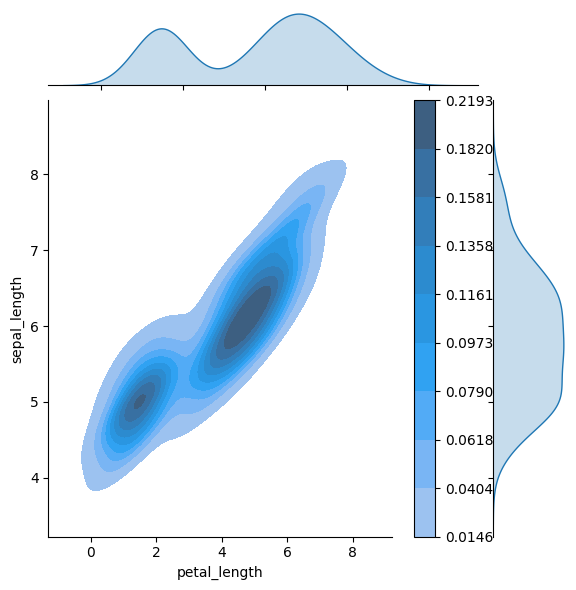

In [128]:
 sns.jointplot(data=df, x="petal_length", y="sepal_length", kind="kde",fill=True,cbar=True)

# transform to normal distribution 

<Axes: xlabel='Age', ylabel='Density'>

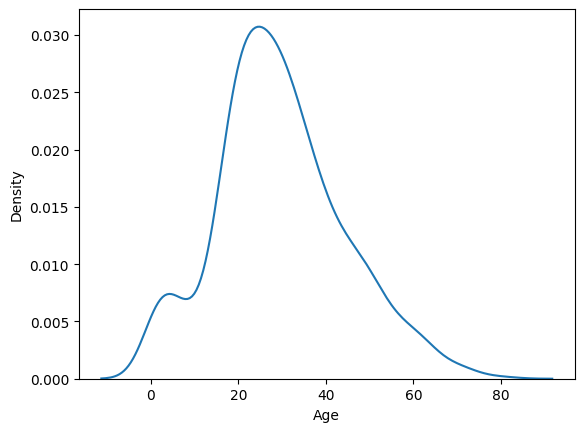

In [129]:
sns.kdeplot(titanic['Age'])

In [130]:
X=(titanic['Age']-titanic['Age'].mean())/titanic['Age'].std()

<Axes: xlabel='Age', ylabel='Density'>

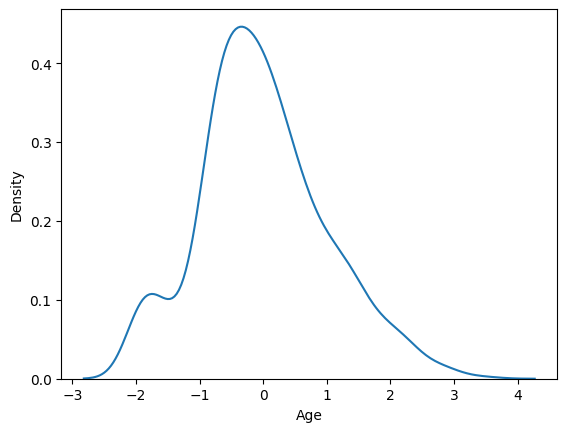

In [131]:
sns.kdeplot(X)

In [132]:
X.mean() #near 0

2.338621049070358e-16

In [133]:
X.std()

1.0

## using normal Distribution to find outliers

In [134]:
titanic['Age'].skew()

0.38910778230082704

In [135]:
titanic['Age'].mean ()+3*titanic['Age'].std()

73.27860964406094

In [136]:
titanic[titanic['Age']>73]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
630,631,1,1,"Barkworth, Mr. Algernon Henry Wilson",male,80.0,0,0,27042,30.000,A23,S
851,852,0,3,"Svensson, Mr. Johan",male,74.0,0,0,347060,7.775,NaN,S


# QQ plot- Normal Distribution

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
df=sns.load_dataset('iris')

In [3]:
df.head(5)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


<Axes: xlabel='sepal_length', ylabel='Density'>

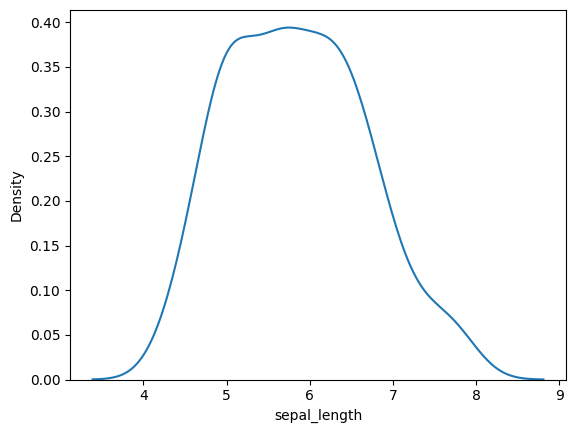

In [4]:
sns.kdeplot(df['sepal_length'])

In [5]:
temp=sorted(df['sepal_length'].tolist())

In [6]:
temp

[4.3,
 4.4,
 4.4,
 4.4,
 4.5,
 4.6,
 4.6,
 4.6,
 4.6,
 4.7,
 4.7,
 4.8,
 4.8,
 4.8,
 4.8,
 4.8,
 4.9,
 4.9,
 4.9,
 4.9,
 4.9,
 4.9,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.1,
 5.1,
 5.1,
 5.1,
 5.1,
 5.1,
 5.1,
 5.1,
 5.1,
 5.2,
 5.2,
 5.2,
 5.2,
 5.3,
 5.4,
 5.4,
 5.4,
 5.4,
 5.4,
 5.4,
 5.5,
 5.5,
 5.5,
 5.5,
 5.5,
 5.5,
 5.5,
 5.6,
 5.6,
 5.6,
 5.6,
 5.6,
 5.6,
 5.7,
 5.7,
 5.7,
 5.7,
 5.7,
 5.7,
 5.7,
 5.7,
 5.8,
 5.8,
 5.8,
 5.8,
 5.8,
 5.8,
 5.8,
 5.9,
 5.9,
 5.9,
 6.0,
 6.0,
 6.0,
 6.0,
 6.0,
 6.0,
 6.1,
 6.1,
 6.1,
 6.1,
 6.1,
 6.1,
 6.2,
 6.2,
 6.2,
 6.2,
 6.3,
 6.3,
 6.3,
 6.3,
 6.3,
 6.3,
 6.3,
 6.3,
 6.3,
 6.4,
 6.4,
 6.4,
 6.4,
 6.4,
 6.4,
 6.4,
 6.5,
 6.5,
 6.5,
 6.5,
 6.5,
 6.6,
 6.6,
 6.7,
 6.7,
 6.7,
 6.7,
 6.7,
 6.7,
 6.7,
 6.7,
 6.8,
 6.8,
 6.8,
 6.9,
 6.9,
 6.9,
 6.9,
 7.0,
 7.1,
 7.2,
 7.2,
 7.2,
 7.3,
 7.4,
 7.6,
 7.7,
 7.7,
 7.7,
 7.7,
 7.9]

In [7]:
y_quant=[]
for i in range(1,101):
    y_quant.append(np.percentile(temp,i))

In [8]:
samples=np.random.normal(loc=0,scale=1,size=1000)

In [9]:
x_quant = []

for i in range(1,101):
  x_quant.append(np.percentile(samples,i))


<Axes: >

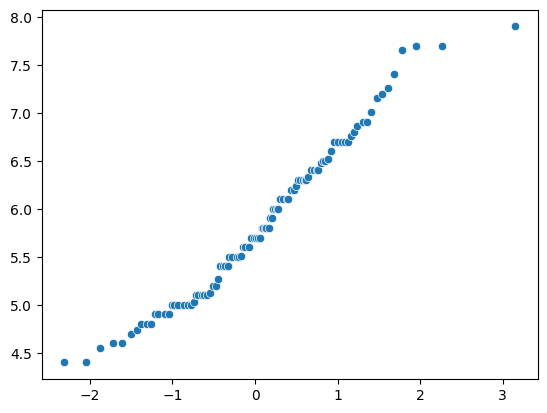

In [10]:
sns.scatterplot(x=x_quant,y=y_quant)

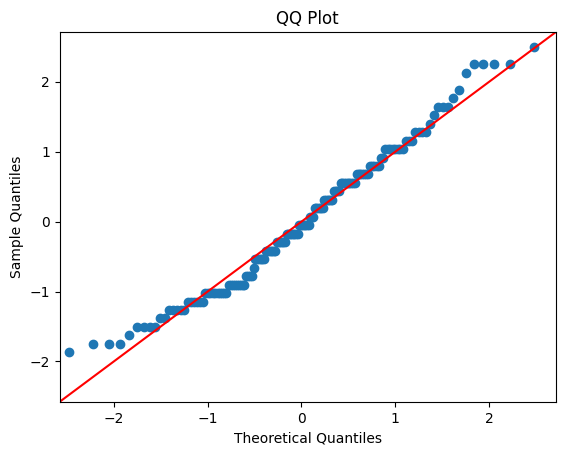

In [22]:
# using statsmodel

import statsmodels.api as sm
import matplotlib.pyplot as plt

#create qq plot
fig=sm.qqplot(df['sepal_length'],line='45',fit=True)

# Add a title and labels to the plot
plt.title('QQ Plot')
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Sample Quantiles')

# Show the plot
plt.show()




# qq plot for uniform distribution

In [14]:
import numpy as np
import scipy.stats as stats
import statsmodels.api as sm
import matplotlib.pyplot as plt


In [21]:
#generate a set of random data
X=np.random.uniform(low=0,high=1,size=1000)

(array([114., 100., 114.,  88.,  93.,  86.,  94., 107., 108.,  96.]),
 array([2.40002608e-04, 1.00163431e-01, 2.00086860e-01, 3.00010289e-01,
        3.99933718e-01, 4.99857147e-01, 5.99780576e-01, 6.99704005e-01,
        7.99627433e-01, 8.99550862e-01, 9.99474291e-01]),
 <BarContainer object of 10 artists>)

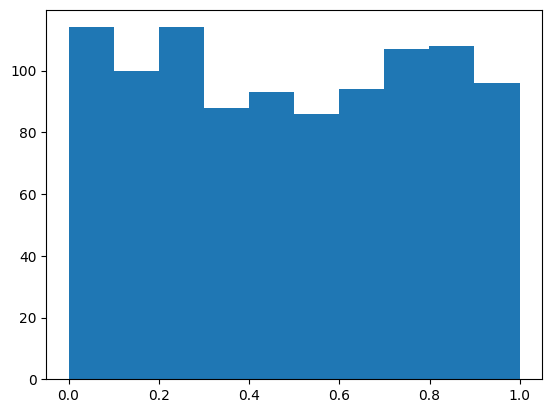

In [25]:
plt.hist(X)

In [26]:
# fit a uniform distiburion to the data
params=stats.uniform.fit(X)
dist=stats.uniform(loc=params[0],scale=params[1])

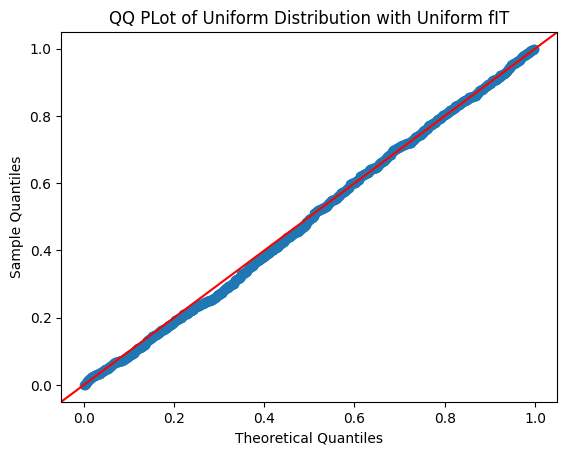

In [36]:
#qq plot
fig=sm.qqplot(X,dist=dist,line='45')

plt.title('QQ PLot of Uniform Distribution with Uniform fIT')
plt.xlabel('Theoretical Quantiles')
plt.ylabel("Sample Quantiles")
plt.show()

# log -Log Plot -Petro Distribution

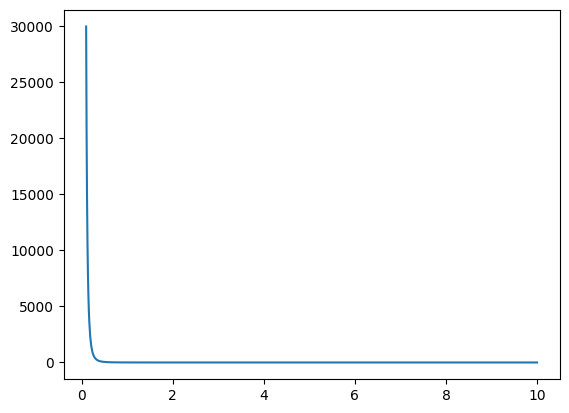

In [42]:
import numpy as np
import matplotlib.pyplot as plt

# Define the parameters of the Pareto distribution
alpha = 3
xm = 1

# Create an array of x values
x = np.linspace(0.1, 10, 1000)

# Calculate the y values of the Pareto distribution
y = alpha * (xm**alpha) / (x**(alpha+1))


plt.plot(x,y)

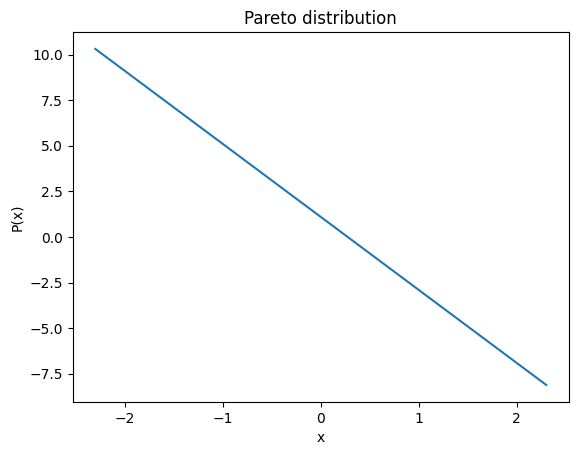

In [43]:
# Create the log-log plot
plt.plot(np.log(x),np.log(y))

# Add labels and a title
plt.xlabel('x')
plt.ylabel('P(x)')
plt.title('Pareto distribution')

# Show the plot
plt.show()

# QQ plot-petro DIstribution

In [44]:
import numpy as np
import scipy.stats as stats
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Define the parameters of the Pareto distribution
alpha = 2
xm = 1

# Generate a set of random data from the Pareto distribution
x = stats.pareto.rvs(b=alpha, scale=xm, size=1000)



(array([967.,  23.,   7.,   1.,   1.,   0.,   0.,   0.,   0.,   1.]),
 array([ 1.00007323,  5.43043757,  9.8608019 , 14.29116624, 18.72153058,
        23.15189492, 27.58225925, 32.01262359, 36.44298793, 40.87335226,
        45.3037166 ]),
 <BarContainer object of 10 artists>)

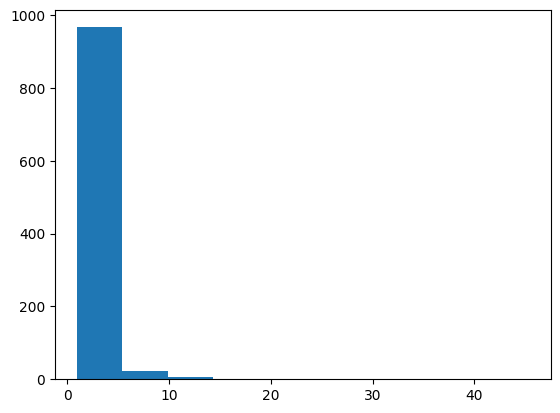

In [45]:
plt.hist(x)

In [46]:
# Fit a Pareto distribution to the data
params = stats.pareto.fit(x, floc=0)

# Create a Pareto distribution object with the fitted parameters
dist = stats.pareto(b=params[0], scale=params[2])


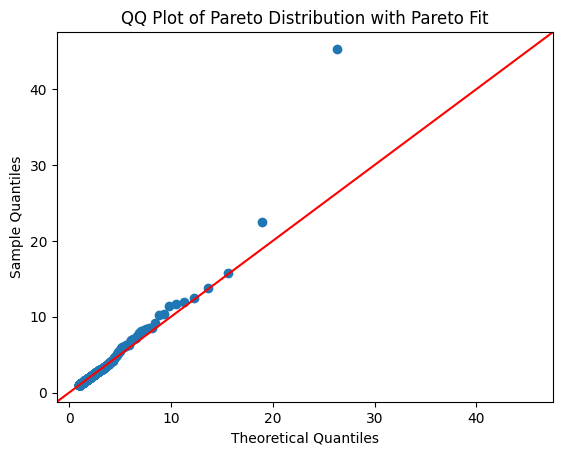

In [47]:
# Create a QQ plot of the data using the Pareto distribution
fig = sm.qqplot(x, dist=dist, line='45')

# Add a title and labels to the plot
plt.title('QQ Plot of Pareto Distribution with Pareto Fit')
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Sample Quantiles')

# Show the plot
plt.show()